In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent  
project_root
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import numpy as np
np.random.seed(42)

In [3]:
from importlib import reload

In [4]:
import pandas as pd
from tqdm import tqdm

In [5]:
from src import data_broker
from src import statioinary_bootstrap
from src import global_state

from src import calendar_iterator
from src import strategy_selector, ad_hoc_strategy

from src import executor_module, performance_evaluator
from src import compliance_filters, budget_allocator
from src import audit

from src import signal_schema
from src import metrics

from src import logging

In [6]:
reload(strategy_selector)

<module 'src.strategy_selector' from '/Users/zhigangyu/Documents/Project Z/src/strategy_selector.py'>

In [7]:
logger=logging.setup_logger(name="backtest_logger", log_file="backtest.log")

In [8]:
import ticker_loader
totak_tickers=ticker_loader.load_total_tickers()
# tickers=run2.get_random_sample(totak_tickers,30)

In [9]:
# 动量亏本 组合
# ','.join(tickers)
# tickers='ALGN,AAPL,PANW,AMD,ZS,MDLZ,XEL,VRSN,INSM,ON,WDAY,ENPH,DLTR,ADI,COST,ABNB,CEG,MSFT,GOOGL,CDNS,PYPL,FAST,JD,MTCH,SNPS,LULU,CMCSA,ADBE,ADSK'.split(',')

In [10]:
# tickers=['SPY','QQQ','QQQE','IWM','XSW','XLY','XLV','XLU','XLRE','XLP','XLK','XLI','XLF','XLE','XLC','XLB','LABU','XBI']#,'VXX']

In [11]:
tickers=totak_tickers

In [12]:
broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()

[******************    38%                       ]  43 of 112 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
[**********************46%                       ]  51 of 112 completed$XLNX: possibly delisted; no timezone found
[**********************54%*                      ]  60 of 112 completed$SGEN: possibly delisted; no timezone found
[**********************62%*****                  ]  69 of 112 completed$WBA: possibly delisted; no timezone found
[**********************76%***********            ]  85 of 112 completed$ATVI: possibly delisted; no timezone found
[**********************78%************           ]  87 of 112 completed$ANSS: possibly delisted; no timezone found
[**********************91%*******************    ]  102 of 112 completed$FI: possibly delisted; no timezone found
[**********************97%********************** ]  109 of 112 completed$SPLK: possibly delisted; no timezone found

In [13]:
universe_data=ticker_loader.fix_data(universe_data)

price shape before drop: (1064, 112)
price shape after drop: (1064, 105)
volume shape after drop: (1064, 105)


In [14]:
bench_tickers=['SPY','QQQ']
bench_broker = data_broker.DataBroker(tickers=bench_tickers, start_date="2022-01-01", end_date="2026-04-01")
bench_universe_data = bench_broker.fetch_universe_data()

[*********************100%***********************]  2 of 2 completed


In [15]:
# adhoc_exit=ad_hoc_strategy.AdHocChandelierExit()

In [16]:
reload(strategy_selector)

<module 'src.strategy_selector' from '/Users/zhigangyu/Documents/Project Z/src/strategy_selector.py'>

In [48]:
risk_adj_moment=strategy_selector.ComprehensiveMultiHorizonStrategy(
    scorer=strategy_selector.SimpleRiskAdjustedScorer(),
    long_window=126,
    short_window=10,
    structural_weight=.6
)

linear_strategy = strategy_selector.ComprehensiveMultiHorizonStrategy(
    scorer=strategy_selector.TraditionalLinearRegressionScorer(),
    long_window=126,
    short_window=10,
    structural_weight=.6
)

# Configuration A: Advanced Risk-Adjusted Blended Momentum
advanced_risk_strat = strategy_selector.ComprehensiveMultiHorizonStrategy(
    scorer=strategy_selector.GeometricDriftScorer(),
    long_window=252,
    short_window=10,
    structural_weight=.6
)

# Configuration B: Advanced Information Discrete Momentum (Time-Weighted)
advanced_info_strat = strategy_selector.ComprehensiveMultiHorizonStrategy(
    scorer=strategy_selector.WeightedLinearRegressionScorer(decay_factor=0.97),
    long_window=126,
    short_window=10,
    structural_weight=.6
)

In [49]:
#126, 10

In [50]:
strategies={'simple_risk':risk_adj_moment,
            'linear_strategy':linear_strategy,
            'advanced_risk_strat':advanced_risk_strat,
            'advanced_info_strat':advanced_info_strat,}

In [51]:
portfolio_filter=compliance_filters.LiquidityComplianceFilter()

# run only on the real data

In [52]:
def run(module_c_regular,module_c1_adhoc=None,is_filter=False,allocation_type='equal'):
    allocator=budget_allocator.IntegratedBudgetAllocator(top_percent=.10, allocation_type=allocation_type)
    g_state=global_state.GlobalState(initial_capital=100_000,core_allocation_pct=1.0)
    executor=executor_module.TransactionExecutor(trade_delay=1)
    calendar = calendar_iterator.CalendarIterator(world_data_dict, interval="ME")
    rebalance_dates = calendar.generate_rebalance_dates()
    
    
    
    # Initialize a formal ledger
    audit_ledger: list[audit.AuditRecord] = []
    logger.info("Initializing Backtest Engine...")
    
    for i, today in enumerate(world_data_dict['price'].index):
        snapshot = calendar.get_historical_snapshot(today)
        market_prices = snapshot['price'].loc[today]
        
        # Initialize containers for this specific time-step's audit trail
        current_telemetry = signal_schema.StrategyTelemetry()
        g_state.signals.clear_signals()
        
        # 1. Strategy Calculation Pass
        regular_strategy_output,adhoc_strategy_output=None, None
        raw_regular_signals,filtered_regular_signals=[],[]
        if today in rebalance_dates and (module_c_regular is not None):
            # Update your strategy to return the StrategyTelemetry object instead of loose info dicts
            regular_strategy_output, current_telemetry = module_c_regular.calculate_signals(snapshot)
            raw_regular_signals = list(regular_strategy_output.signals)
            if is_filter:
                regular_strategy_output = portfolio_filter.filter_signals(today, regular_strategy_output, snapshot)
                filtered_regular_signals=list(regular_strategy_output.signals)
            else:
                filtered_regular_signals=raw_regular_signals
    
            if regular_strategy_output.signals:
                logger.info(f"=== REBALANCE EVENT TRIGGERED: {today.strftime('%Y-%m-%d')} ===")
    
        raw_adhoc_signals,filtered_adhoc_signals=[],[]
        if module_c1_adhoc is not None:
            adhoc_strategy_output = module_c1_adhoc.evaluate_exits(g_state, snapshot)
            raw_adhoc_signals= list(adhoc_strategy_output.signals)
            adhoc_strategy_output = portfolio_filter.filter_signals(today, adhoc_strategy_output, snapshot)
            filtered_adhoc_signals=list(adhoc_strategy_output.signals)
        g_state.signals.update_signals(regular_strategy_output,adhoc_strategy_output)
        
    
        # 2. Allocation Pass
        core_target_weights, sell_adhoc_orders, buy_adhoc_orders = allocator.allocate_capital(
             g_state, market_prices,
        ) 
        
        
        g_state.need_trade.set_core(core_target_weights, today)
        g_state.need_trade.set_sell_adhoc(sell_adhoc_orders, today)
        g_state.need_trade.set_buy_adhoc(buy_adhoc_orders, today)
        
        # 3. Execution & Portfolio State Capture
        # (Capture the current trades before or during execution context if needed)
        executor.execute_trades(g_state, today, market_prices)
        g_state.record_daily_snapshot(today, market_prices)
        
        # 4. Commit to Audit Ledger only on actionable days to save memory, 
        # or every day depending on your debugging requirements
        if today in rebalance_dates and len(getattr(current_telemetry,'metrics',{}))!=0:
            
            audit_ledger.append(audit.AuditRecord(
                date=today,
                telemetry=current_telemetry,
                raw_regular_signals=raw_regular_signals,
                filtered_regular_signals=filtered_regular_signals,
                raw_adhoc_signals=raw_adhoc_signals,
                filtered_adhoc_signals=filtered_adhoc_signals,
                target_weights=core_target_weights,
                executed_trades=[] # Populate from executor if your executor keeps track
            ))
    
    logger.info("Backtest execution completed successfully.")
    return g_state

In [53]:
world_data_dict= universe_data

In [54]:
reload(executor_module)

<module 'src.executor_module' from '/Users/zhigangyu/Documents/Project Z/src/executor_module.py'>

In [55]:
states={}
for strat_name in strategies:
    print(f'******* {strat_name} *******')
    strategy=strategies[strat_name]
    state=run(strategy)#,allocation_type='score_weighted')
    states[strat_name]=state

******* simple_risk *******
[2026-07-06 23:41:53] INFO [backtest_logger]: Initializing Backtest Engine...
[2026-07-06 23:41:53] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2022-07-29 ===
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY ENPH ... 32.3@280.89, fee: 9.08
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY ADP ... 41.18@220.32, fee: 9.08
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY SMCI ... 1642.42@5.52, fee: 9.08
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY SNPS ... 24.52@370.01, fee: 9.08
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY AEP ... 105.98@85.61, fee: 9.08
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY ON ... 142.52@63.66, fee: 9.08
[2026-07-06 23:41:53] INFO [backtest_logger]:     2022-08-01 00:00:00:CORE_BUY MNST ... 184.24@49.24, fee: 9.08
[2026-07-06 23:41:53] I

# analysis

In [56]:
from src import analysis

In [57]:
def evaluate(g_state,effective_date='2023-01-01'):
    g_state.display_current_state(today,market_prices)
    df_nav=g_state.export_nav_dataframe()
    df_nav_effect=df_nav.loc[df_nav.index>='2023-01-01']
    print(metrics.calculate_metrics(df_nav_effect))
    return df_nav_effect



In [58]:
effective_date='2023-01-31'
bench_price=bench_universe_data['price']

In [59]:
df_nav_list=[]
for strat_name in states:
    print(strat_name)
    g_state=states[strat_name]
    df_nav=g_state.export_nav_dataframe()[['Total_NAV']]
    df_nav=df_nav.rename({'Total_NAV':strat_name},axis=1)
    df_nav_list.append(df_nav)

simple_risk
linear_strategy
advanced_risk_strat
advanced_info_strat


In [60]:
df1=pd.concat([bench_price]+df_nav_list,axis=1)
df2=df1.loc[effective_date:]

In [46]:
# df_prices=universe_data['price'】

In [61]:
metrics.calculate_metrics(df2)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
SPY,0.175828,1.377511,2.295794,0.187552,0.937488
QQQ,0.244466,1.455030,2.455618,0.227683,1.073710
simple_risk,0.212723,1.331052,2.201151,0.148967,1.427987
linear_strategy,0.246048,1.274427,2.143704,0.238115,1.033318
advanced_risk_strat,0.203861,1.107220,1.851649,0.218508,0.932968
advanced_info_strat,0.248261,1.294050,2.162892,0.279547,0.888085


In [47]:
metrics.calculate_metrics(df2)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
SPY,0.175828,1.377511,2.295794,0.187552,0.937488
QQQ,0.244466,1.455030,2.455618,0.227683,1.073710
simple_risk,0.240181,1.274107,2.188462,0.209195,1.148121
linear_strategy,0.153771,0.781633,1.252169,0.324883,0.473311
advanced_risk_strat,0.206398,1.005115,1.629795,0.264491,0.780358
advanced_info_strat,0.132262,0.709182,1.136810,0.329811,0.401024


In [31]:
# analysis.plot_rebased_performance(df_prices)

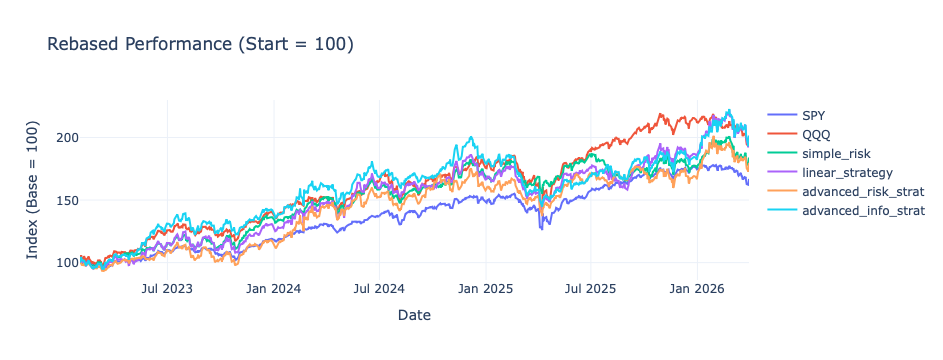

In [62]:
analysis.plot_rebased_performance(df2)#['2025-04-01':])

## 不同趋势

In [49]:
df3=df2.loc['2025-04-01':]

In [50]:
metrics.calculate_metrics(df3)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
SPY,0.173245,1.124137,1.887492,0.120527,1.437390
QQQ,0.227800,1.225792,2.111929,0.126200,1.805078
simple_risk,0.081380,0.581347,0.951950,0.111693,0.728611
linear_strategy,0.043313,0.354572,0.560538,0.170578,0.253920
advanced_risk_strat,0.218013,1.151778,1.892588,0.127808,1.705788
advanced_info_strat,0.281606,1.371513,2.195485,0.125645,2.241288


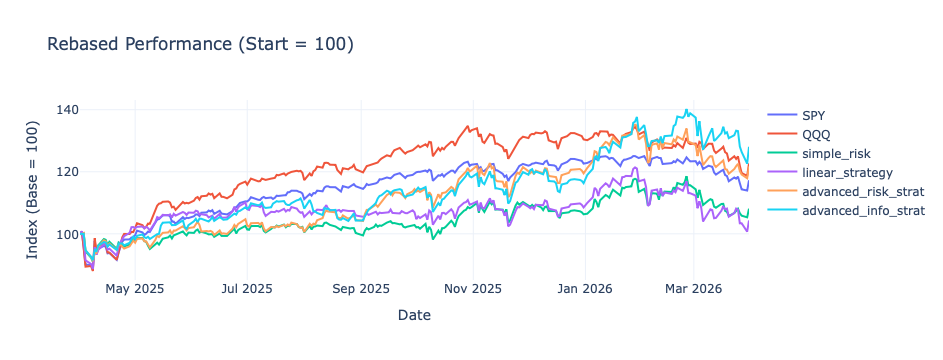

In [51]:
analysis.plot_rebased_performance(df3)

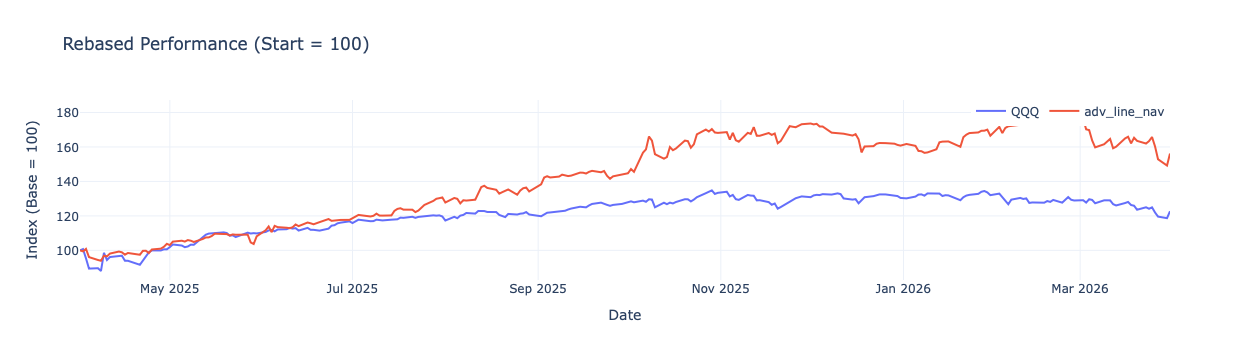

In [142]:
analysis.plot_rebased_performance(df2.loc['2025-04-01':,['QQQ','adv_line_nav']])

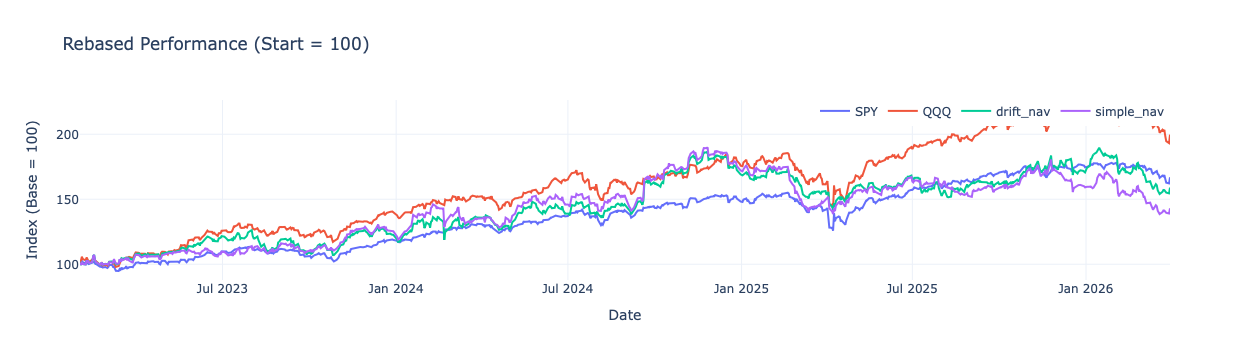

In [69]:
metrics.calculate_metrics(df2)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
SPY,0.175828,1.377511,2.295793,0.187552,0.937488
QQQ,0.244466,1.455030,2.455618,0.227683,1.073711
simple_risk,0.106311,0.896535,1.453871,0.139828,0.760298
linear_strategy,0.065493,0.465521,0.767382,0.187872,0.348606
advanced_risk_strat,0.076956,0.600480,0.991062,0.202483,0.380062
advanced_info_strat,0.295452,1.387205,2.417199,0.249873,1.182410


In [70]:
df2_vxx=df2

In [50]:
df_nav_effect=evaluate(g_state,effective_date='2023-01-01')

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.1% Cash
  - Core Liquid Cash : $114.65
  - Total Core NAV   : $158,961.07
          Shares    Price Market Value Sleeve Weight
Ticker                                              
ADI     163.2926  $318.14   $51,949.92        32.68%
XEL     692.9367   $78.85   $54,634.84        34.37%
DLTR    477.2319  $109.51   $52,261.66        32.88%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $158,961.07
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------

                  CAGR  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  \
Core_NAV      0.153847      0.879248       1.446477      0.239168   
Tactical_NAV       NaN        

In [24]:
# risk_adj_moment
g_state.display_current_state(today,market_prices)

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.1% Cash
  - Core Liquid Cash : $103.16
  - Total Core NAV   : $143,029.93
          Shares    Price Market Value Sleeve Weight
Ticker                                              
ADI     146.9278  $318.14   $46,743.62        32.68%
XEL     623.4894   $78.85   $49,159.24        34.37%
DLTR    429.4029  $109.51   $47,023.91        32.88%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $143,029.93
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------



In [24]:
# advanced_risk_strat
g_state.display_current_state(today,market_prices)

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.1% Cash
  - Core Liquid Cash : $114.65
  - Total Core NAV   : $158,961.07
          Shares    Price Market Value Sleeve Weight
Ticker                                              
ADI     163.2926  $318.14   $51,949.92        32.68%
XEL     692.9367   $78.85   $54,634.84        34.37%
DLTR    477.2319  $109.51   $52,261.66        32.88%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $158,961.07
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------



In [115]:
# for linear_strategy
g_state.display_current_state(today,market_prices)

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.0% Cash
  - Core Liquid Cash : $0.07
  - Total Core NAV   : $91,593.24
          Shares    Price Market Value Sleeve Weight
Ticker                                              
ADI      97.6386  $318.14   $31,062.73        33.91%
ALGN      0.0000  $171.43        $0.00         0.00%
PANW      0.0000  $160.32        $0.00         0.00%
CEG     104.9394  $278.82   $29,258.86        31.94%
XEL       0.0000   $78.85        $0.00         0.00%
DLTR    285.5592  $109.51   $31,271.58        34.14%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $91,593.24
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------



In [118]:
# for advanced info strategy
g_state.display_current_state(today,market_prices)

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.0% Cash
  - Core Liquid Cash : $0.10
  - Total Core NAV   : $129,977.29
           Shares    Price Market Value Sleeve Weight
Ticker                                               
ENPH    1092.8974   $37.81   $41,322.45        31.79%
ALGN     258.5094  $171.43   $44,316.26        34.10%
ADI      139.3678  $318.14   $44,338.48        34.11%
INSM       0.0000  $163.52        $0.00         0.00%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $129,977.29
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------



## daily level

In [25]:
from src import analysis

In [61]:
reload(analysis)

<module 'src.analysis' from '/Users/zhigangyu/Documents/Project Z/src/analysis.py'>

In [26]:
metric_keys=audit_ledger[0].telemetry.metrics.keys()
df_ledger=audit.analyze_audit_trail(audit_ledger,metric_keys)
df_ledger.shape

(1131, 9)

In [27]:
df_nav=g_state.export_nav_dataframe()[['Total_NAV']]
df_nav=df_nav.rename({'Total_NAV':'nav'},axis=1)

In [28]:
df_trade=analysis.parse_backtest_log('backtest.log')
df_trade['shares2']=np.where(df_trade['type']=='CORE_SELL',-1*df_trade['shares'],df_trade['shares'])

In [29]:
df_ledger['trade_date']=df_ledger['date']+ pd.Timedelta(days=1)

In [30]:
df_trade2=df_trade.merge(df_ledger[['trade_date','ticker','final_weight']],left_on=['date','ticker'],right_on=['trade_date','ticker'])

In [31]:
df_trade2

,date,type,ticker,shares,price,fee,shares2,trade_date,final_weight
0,2023-02-01,CORE_BUY,SNPS,90.63,367.05,33.30,90.63,2023-02-01,0.333333
1,2023-02-01,CORE_BUY,ON,427.37,77.84,33.30,427.37,2023-02-01,0.333333
2,2023-02-01,CORE_BUY,CDNS,176.12,188.89,33.30,176.12,2023-02-01,0.333333
3,2023-03-01,CORE_SELL,ON,427.37,78.23,33.43,-427.37,2023-03-01,0.000000
4,2023-03-01,CORE_SELL,CDNS,2.05,191.43,0.39,-2.05,2023-03-01,0.333333
...,...,...,...,...,...,...,...,...,...
82,2025-10-01,CORE_SELL,INSM,373.10,147.28,54.95,-373.10,2025-10-01,0.000000
83,2025-10-01,CORE_SELL,FAST,1116.95,46.96,52.45,-1116.95,2025-10-01,0.000000
84,2025-10-01,CORE_BUY,XEL,685.36,78.52,53.87,685.36,2025-10-01,0.333333
85,2025-10-01,CORE_BUY,GOOGL,220.16,244.42,53.87,220.16,2025-10-01,0.333333


In [32]:
df_trade3=analysis.generate_balance_df(df_trade,daily_resolution=False)
df_trade3=analysis.unpivot_balance_df(df_trade3)
df_trade3.head()

,date,ticker,shares
6,2023-02-01,CDNS,176.12
17,2023-02-01,ON,427.37
20,2023-02-01,SNPS,90.63
28,2023-03-01,ADI,190.84
31,2023-03-01,CDNS,174.07


In [33]:
df_trade3.head(10)

,date,ticker,shares
6,2023-02-01,CDNS,176.12
17,2023-02-01,ON,427.37
20,2023-02-01,SNPS,90.63
28,2023-03-01,ADI,190.84
31,2023-03-01,CDNS,174.07
45,2023-03-01,SNPS,92.29
53,2023-04-03,ADI,193.52
56,2023-04-03,CDNS,170.84
65,2023-04-03,MDLZ,562.23
70,2023-04-03,SNPS,-0.01


In [213]:
reload(analysis)

<module 'src.analysis' from '/Users/zhigangyu/Documents/Project Z/src/analysis.py'>

In [34]:
df_prices=universe_data['price']
df_prices.index.name='date'

In [35]:
df_enhanced_ledger=analysis.build_enhanced_ledger_from_balances(df_trade3,df_prices)

In [36]:
# chech the nav by g_state record and our log history, mainly match
df1=df_enhanced_ledger.loc[df_enhanced_ledger['is_rebalance_day']]
df2=df1.groupby('date')[['current_value']].sum()
df_nav_match=df_nav.merge(df2, right_index=True,left_index=True)

In [37]:
df_nav_diff=df_nav_match.diff()
df_nav_diff.sort_values('nav').head()

,nav,current_value
Date,,
2025-01-02,-13090.253861,-13195.169994
2025-08-01,-12219.188676,-12313.880605
2026-03-02,-11803.938025,-11854.378509
2023-10-02,-9897.035718,-9933.959723
2025-03-03,-8561.390895,-8501.522291


In [40]:

idx=df_enhanced_ledger['cum_pnl'].idxmin()
print(df_enhanced_ledger.loc[idx])
lost_ticker=df_enhanced_ledger.loc[idx]['ticker']
df1=df_trade3.loc[df_trade3['ticker']==lost_ticker]

date                2026-02-05 00:00:00
ticker                              AMD
shares_holding                   248.09
current_price                     192.5
current_value                 47757.325
yesterday_value            49665.137706
return_change                 -0.038414
pnl_dollar                 -1907.812706
entry_price                  246.274345
cum_pnl                    -13340.87726
weight                         0.282397
shares_change                       0.0
is_rebalance_day                  False
Name: 29760, dtype: object


In [41]:
first_date=df1.iloc[0]['date']+pd.Timedelta(days=-10)
last_date=df1.iloc[-1]['date']+pd.Timedelta(days=+10)

In [42]:
df2=df_enhanced_ledger.loc[(df_enhanced_ledger['date']>=first_date)&(df_enhanced_ledger['date']<=last_date)]

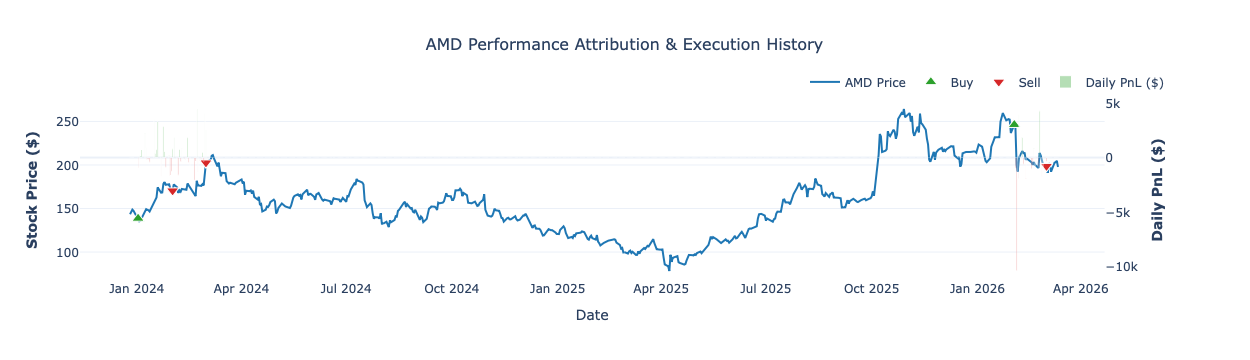

In [43]:
analysis.plot_ticker_attribution(df2,ticker_symbol=lost_ticker)

## evaluation

In [44]:
from src import metrics

In [45]:
print('info_moment')

info_moment


# evaluateion on bootstrap results

In [23]:
from src import stat_test

In [24]:
def nav_all(nav_list,col='Total_NAV'):
    nav_all=pd.concat([nav[col] for nav in nav_list],axis=1)
    nav_all.columns=range(0,len(nav_list))
    return nav_all

In [25]:
risk_nav_all=nav_all(risk_navs)
risk_nav_metrics=metrics.calculate_metrics(risk_nav_all)

In [26]:
info_nav_all=nav_all(info_navs)
info_nav_metrics=metrics.calculate_metrics(info_nav_all)

In [27]:
risk_nav_metrics.columns

Index(['CAGR', 'Sharpe_Ratio', 'Sortino_Ratio', 'Max_Drawdown',
       'Calmar_Ratio'],
      dtype='str')

In [40]:
for column in risk_nav_metrics.columns:
    print(f'----{column}----')
    s1,s2=risk_nav_metrics[column],info_nav_metrics[column]
    # test_res=stat_test.test_paired_series_non_parametric(s1,s2)
    test_res=stat_test.automated_paired_test(s1,s2)
    if not test_res['significant_at_5pct']:
        print(f'different: {s1.mean()} ..vs.. {s2.mean()}')
    else:
        print(f'same: {s1.mean()} ..vs.. {s2.mean()}')

----CAGR----
same: 0.1799114853780623 ..vs.. 0.1924236832228953
----Sharpe_Ratio----
same: 0.7392562372772251 ..vs.. 0.6993231332027183
----Sortino_Ratio----
same: 1.876469755704342 ..vs.. 1.8034742959731789
----Max_Drawdown----
same: 0.2614017594246385 ..vs.. 0.29531564838493124
----Calmar_Ratio----
same: 0.9910205376658745 ..vs.. 0.9232063324783212


array([[<Axes: title={'center': 'CAGR'}>]], dtype=object)

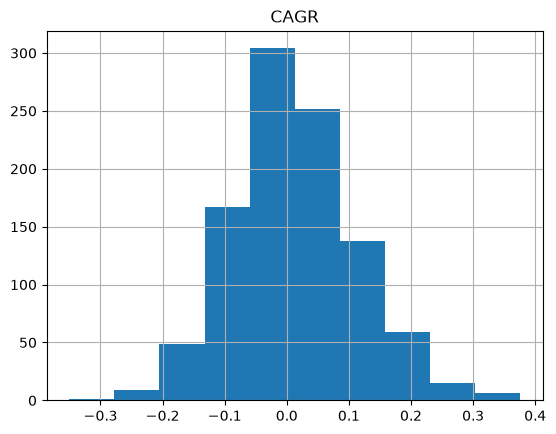

In [39]:
(info_nav_metrics[['CAGR']]-risk_nav_metrics[['CAGR']]).hist()

# benchmark

In [30]:
engine_bench,prices_3d,volume_3d=run2.get_bootstrap_words(bench_universe_data,NUM_SIMULATIONS)

In [31]:
# Run the Macro Orchestrator validation pass
spy_navs=[]
qqq_navs=[]

for sim_id in tqdm(range(NUM_SIMULATIONS)):
    # Pack the 3D slices into clean 2D DataFrames with the ORIGINAL calendar dates index
    # world_data_dict = {
    #     'price': pd.DataFrame(prices_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers),
    #     'volume': pd.DataFrame(volume_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers)
    # }
    df_prices=pd.DataFrame(prices_3d[sim_id, :, :], index=engine_bench.dates_index, columns=engine_bench.tickers)
    spy_navs.append(df_prices[['SPY']])
    qqq_navs.append(df_prices[['QQQ']])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1313.10it/s]


In [32]:
assert len(spy_navs)==len(qqq_navs)==NUM_SIMULATIONS

In [33]:
spy_nav_all=nav_all(spy_navs,'SPY')
qqq_nav_all=nav_all(qqq_navs,'QQQ')

In [34]:
sqy_nav_metrics=metrics.calculate_metrics(spy_nav_all)
qqq_nav_metrics=metrics.calculate_metrics(qqq_nav_all)

In [35]:
for column in sqy_nav_metrics.columns:
    print(f'----{column}----')
    s1,s2=sqy_nav_metrics[column],qqq_nav_metrics[column]
    test_res=stat_test.test_paired_series_non_parametric(s1,s2)
    if not test_res['significant_at_5pct']:
        print(f'different: {s1.mean()} ..vs.. {s2.mean()}')
    else:
        print(f'same: {s1.mean()} ..vs.. {s2.mean()}')

----CAGR----
same: 0.09446482332172962 ..vs.. 0.10137824440424797
----Sharpe_Ratio----
same: 0.7289833702412534 ..vs.. 0.6374972764882084
----Sortino_Ratio----
same: 1.220004877043697 ..vs.. 1.0713361812131421
----Max_Drawdown----
same: 0.25675941436112626 ..vs.. 0.34280337500446895
----Calmar_Ratio----
same: 0.46998721726869935 ..vs.. 0.39476742605700077
